In [51]:
import json
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

In [52]:
fn = "../enterprise-attack/enterprise-attack.json"
with open(fn, "r", encoding="utf-8") as f:
    stix = json.load(f)

objects = stix.get("objects", [])


In [53]:
rel_objs = [o for o in objects if o.get("type") == "relationship"]

rel_df = pd.DataFrame([{
    "id": o.get("id"),
    "relationship_type": o.get("relationship_type"),
    "source_ref": o.get("source_ref"),
    "target_ref": o.get("target_ref"),
    "description": o.get("description"),
    "raw": o
} for o in rel_objs])

rel_df.head()


,id,relationship_type,source_ref,target_ref,description,raw
0,relationship--00038d0e-7fc7-41c3-9055-edb4d87e...,uses,malware--6a21e3a4-5ffe-4581-af9a-6a54c7536f44,attack-pattern--707399d6-ab3e-4963-9315-d9d381...,[Explosive](https://attack.mitre.org/software...,"{'type': 'relationship', 'spec_version': '2.1'..."
1,relationship--0005fb3b-274a-4ac1-8fb2-51366fcd...,mitigates,course-of-action--21da4fd4-27ad-4e9c-b93d-0b9b...,attack-pattern--43c9bc06-715b-42db-972f-52d25c...,Consider blocking download/transfer and execut...,"{'type': 'relationship', 'spec_version': '2.1'..."
2,relationship--000aa4d0-315e-40d7-b2b6-76e91ecf...,uses,intrusion-set--01e28736-2ffc-455b-9880-ed4d140...,attack-pattern--65f2d882-3f41-4d48-8a06-29af77...,[Indrik Spider](https://attack.mitre.org/group...,"{'type': 'relationship', 'spec_version': '2.1'..."
3,relationship--00192a5f-9dc0-445a-b010-d77bd08a...,uses,malware--425771c5-48b4-4ecd-9f95-74ed3fc9da59,attack-pattern--bf176076-b789-408e-8cba-7275e8...,[SombRAT](https://attack.mitre.org/software/S0...,"{'type': 'relationship', 'spec_version': '2.1'..."
4,relationship--001ecf24-8276-40d2-ba05-2d20e5c5...,uses,malware--b7010785-699f-412f-ba49-524da6033c76,attack-pattern--132d5b37-aac5-4378-a8dc-3127b1...,[GoldFinder](https://attack.mitre.org/software...,"{'type': 'relationship', 'spec_version': '2.1'..."


Map techniques to tactics (exploded rows, easy to group)

In [54]:
# Filter relationships where source is intrusion-set and target is attack-pattern (technique)
rel_uses = rel_df[
    (rel_df["relationship_type"] == "uses") &
    (rel_df["source_ref"].str.startswith("intrusion-set")) &
    (rel_df["target_ref"].str.startswith("attack-pattern"))
].copy()

# Map intrusion-set names
rel_uses["intrusion_set_name"] = rel_uses["source_ref"].map(intrusion_map)

# Join in technique info (external_id and name)
rel_uses = rel_uses.merge(
    tech_df[["id", "external_id", "tech_name"]],
    left_on="target_ref", right_on="id", how="left"
)

rel_uses.head()


,id_x,relationship_type,source_ref,target_ref,description,raw,intrusion_set_name,id_y,external_id,tech_name
0,relationship--000aa4d0-315e-40d7-b2b6-76e91ecf...,uses,intrusion-set--01e28736-2ffc-455b-9880-ed4d140...,attack-pattern--65f2d882-3f41-4d48-8a06-29af77...,[Indrik Spider](https://attack.mitre.org/group...,"{'type': 'relationship', 'spec_version': '2.1'...",Indrik Spider,attack-pattern--65f2d882-3f41-4d48-8a06-29af77...,T1003.001,LSASS Memory
1,relationship--002f1039-f4c5-4c60-b8ac-ced374be...,uses,intrusion-set--b7f627e2-0817-4cd5-8d50-e75f8aa...,attack-pattern--10ffac09-e42d-4f56-ab20-db94c6...,[LuminousMoth](https://attack.mitre.org/groups...,"{'type': 'relationship', 'spec_version': '2.1'...",LuminousMoth,attack-pattern--10ffac09-e42d-4f56-ab20-db94c6...,T1539,Steal Web Session Cookie
2,relationship--003071c1-a640-4f29-8405-a3998dfa...,uses,intrusion-set--918da025-04bd-48af-b6c4-f3e4d1b...,attack-pattern--f5d8eed6-48a9-4cdf-a3d7-d1ffa9...,[Medusa Group](https://attack.mitre.org/groups...,"{'type': 'relationship', 'spec_version': '2.1'...",Medusa Group,attack-pattern--f5d8eed6-48a9-4cdf-a3d7-d1ffa9...,T1490,Inhibit System Recovery
3,relationship--0038b0b8-f51c-4fd1-8b04-2fd7ebd1...,uses,intrusion-set--dd2d9ca6-505b-4860-a604-233685b...,attack-pattern--635cbe30-392d-4e27-978e-667743...,[Wizard Spider](https://attack.mitre.org/group...,"{'type': 'relationship', 'spec_version': '2.1'...",Wizard Spider,attack-pattern--635cbe30-392d-4e27-978e-667743...,T1136.001,Local Account
4,relationship--00561c3c-345e-4578-95c3-b7e0a95d...,uses,intrusion-set--3753cc21-2dae-4dfb-8481-d004e74...,attack-pattern--ef67e13e-5598-4adc-bdb2-998225...,[FIN7](https://attack.mitre.org/groups/G0046) ...,"{'type': 'relationship', 'spec_version': '2.1'...",FIN7,attack-pattern--ef67e13e-5598-4adc-bdb2-998225...,T1204.001,Malicious Link


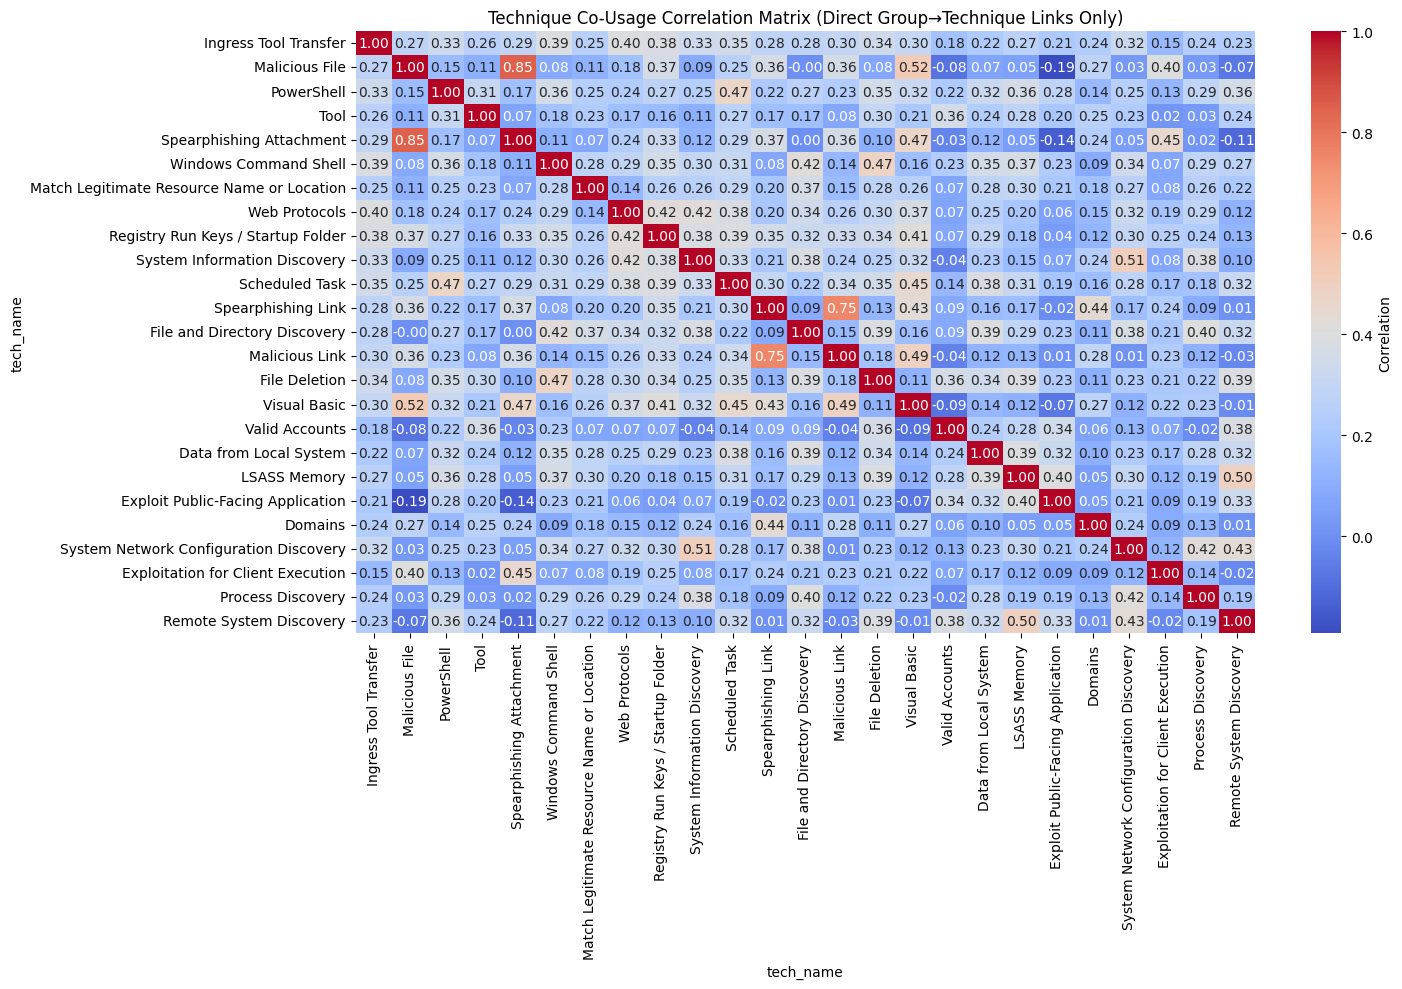

In [55]:
# Use ONLY direct group→technique relationships (already created earlier as rel_uses)
direct_df = rel_uses[["intrusion_set_name", "external_id", "tech_name"]].dropna()

# 1️⃣ Pivot into a binary matrix:
# Rows = intrusion sets, Columns = techniques, Values = 1 if group uses technique
usage_matrix_direct = (
    direct_df
    .assign(value=1)
    .pivot_table(
        index="intrusion_set_name",
        columns="tech_name",
        values="value",
        fill_value=0
    )
)

# 2️⃣ Compute correlation between techniques
corr_matrix_direct = usage_matrix_direct.corr()

# 3️⃣ (Optional) Focus on the top N most-used techniques to keep visualization readable
top_techs_direct = (
    direct_df.groupby("tech_name")["intrusion_set_name"]
    .nunique()
    .sort_values(ascending=False)
    .head(25)
    .index
)

corr_subset_direct = corr_matrix_direct.loc[top_techs_direct, top_techs_direct]

# 4️⃣ Visualize as a heatmap
plt.figure(figsize=(15,10))
sns.heatmap(
    corr_subset_direct,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Correlation"},
)
plt.title("Technique Co-Usage Correlation Matrix (Direct Group→Technique Links Only)")
plt.tight_layout()
plt.show()


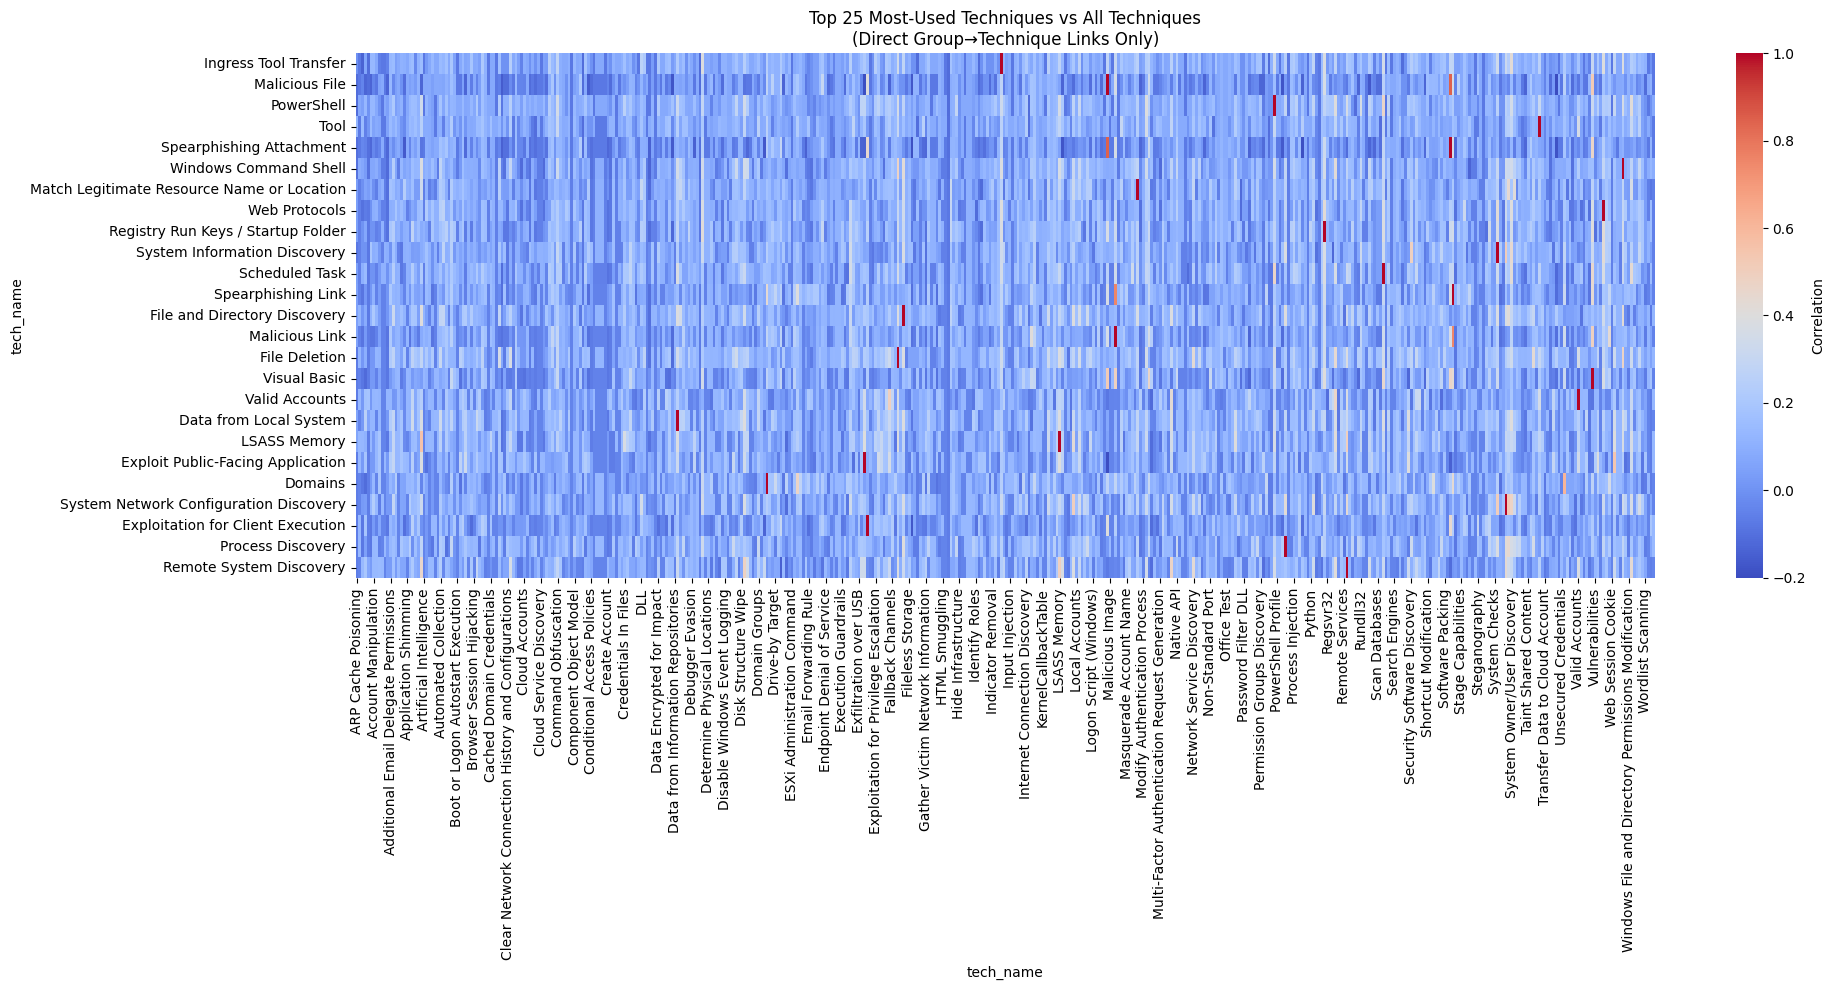

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️⃣ Use only direct group→technique relationships ---
direct_df = rel_uses[["intrusion_set_name", "external_id", "tech_name"]].dropna()

# --- 2️⃣ Pivot into a binary matrix (group x technique) ---
usage_matrix_direct = (
    direct_df
    .assign(value=1)
    .pivot_table(
        index="intrusion_set_name",
        columns="tech_name",
        values="value",
        fill_value=0
    )
)

# --- 3️⃣ Compute correlation between techniques ---
corr_matrix_direct = usage_matrix_direct.corr()

# --- 4️⃣ Find top 25 most frequently used techniques ---
top_techs_direct = (
    direct_df.groupby("tech_name")["intrusion_set_name"]
    .nunique()
    .sort_values(ascending=False)
    .head(25)
    .index
)

# --- 5️⃣ Subset correlations: Top 25 (rows) vs ALL techniques (columns) ---
corr_subset_direct = corr_matrix_direct.loc[top_techs_direct, :]

# --- 6️⃣ Visualize ---
plt.figure(figsize=(20, 10))
sns.heatmap(
    corr_subset_direct,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Correlation"},
)
plt.title("Top 25 Most-Used Techniques vs All Techniques\n(Direct Group→Technique Links Only)")
plt.tight_layout()
plt.show()



In [57]:

# --- 1️⃣ Use only direct group→technique relationships ---
direct_df = rel_uses[["intrusion_set_name", "external_id", "tech_name"]].dropna()

# --- 2️⃣ Pivot into binary matrix (group x technique) ---
usage_matrix_direct = (
    direct_df
    .assign(value=1)
    .pivot_table(
        index="intrusion_set_name",
        columns="tech_name",
        values="value",
        fill_value=0
    )
)

# --- 3️⃣ Compute correlation between techniques ---
corr_matrix_direct = usage_matrix_direct.corr()

# --- 4️⃣ Find top 25 most frequently used techniques ---
top_techs_direct = (
    direct_df.groupby("tech_name")["intrusion_set_name"]
    .nunique()
    .sort_values(ascending=False)
    .head(25)
    .index
)

# --- 5️⃣ Threshold and filtering parameters ---
THRESHOLD = 0.4

results = {}

for tech in top_techs_direct:
    # Get all correlations > threshold, excluding itself
    strong_corrs = corr_matrix_direct[tech][corr_matrix_direct[tech] > THRESHOLD].drop(tech)
    
    # Exclude other top 25 techniques
    strong_corrs = strong_corrs[~strong_corrs.index.isin(top_techs_direct)]
    
    if not strong_corrs.empty:
        results[tech] = list(strong_corrs.sort_values(ascending=False).items())

# --- 6️⃣ Print results cleanly ---
for tech, corrs in results.items():
    print(f"\n{tech}:")
    for other, val in corrs:
        print(f"  → {other}: {val:.3f}")



Ingress Tool Transfer:
  → System Owner/User Discovery: 0.420

PowerShell:
  → Windows Management Instrumentation: 0.415
  → Remote Desktop Protocol: 0.402

Windows Command Shell:
  → Remote Desktop Protocol: 0.422

Match Legitimate Resource Name or Location:
  → System Network Connections Discovery: 0.437
  → System Service Discovery: 0.410

Web Protocols:
  → System Owner/User Discovery: 0.402

Registry Run Keys / Startup Folder:
  → Deobfuscate/Decode Files or Information: 0.411

System Information Discovery:
  → Security Software Discovery: 0.489
  → System Owner/User Discovery: 0.441

Scheduled Task:
  → Windows Management Instrumentation: 0.437
  → System Owner/User Discovery: 0.420

Spearphishing Link:
  → Email Accounts: 0.404

File and Directory Discovery:
  → System Network Connections Discovery: 0.414
  → Archive via Utility: 0.408

Malicious Link:
  → Web Services: 0.430
  → JavaScript: 0.410

File Deletion:
  → Remote Desktop Protocol: 0.441
  → Timestomp: 0.431
  → Netwo

In [58]:
# --- 1️⃣ Start with top 25 most-used techniques ---
all_techs_set = set(top_techs_direct)

# --- 2️⃣ Add all correlated techniques from previous step ---
for corrs in results.values():  # 'results' from previous step
    for other, _ in corrs:
        all_techs_set.add(other)

# --- 3️⃣ Convert to sorted list ---
all_techs_list = sorted(all_techs_set)

# --- 4️⃣ Display ---
print(f"Total unique techniques: {len(all_techs_list)}")
for tech in all_techs_list:
    print(tech)

Total unique techniques: 47
Archive via Utility
Data from Local System
Deobfuscate/Decode Files or Information
Domain Account
Domains
Email Accounts
Exploit Public-Facing Application
Exploitation for Client Execution
External Remote Services
File Deletion
File and Directory Discovery
Ingress Tool Transfer
JavaScript
LSASS Memory
Local Account
Malicious File
Malicious Link
Match Legitimate Resource Name or Location
Mshta
NTDS
Network Service Discovery
Pass the Hash
PowerShell
Process Discovery
Query Registry
Registry Run Keys / Startup Folder
Remote Desktop Protocol
Remote System Discovery
Scheduled Task
Security Software Discovery
Spearphishing Attachment
Spearphishing Link
System Information Discovery
System Network Configuration Discovery
System Network Connections Discovery
System Owner/User Discovery
System Service Discovery
Timestomp
Tool
Upload Malware
Valid Accounts
Visual Basic
Web Protocols
Web Services
Web Shell
Windows Command Shell
Windows Management Instrumentation
